<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


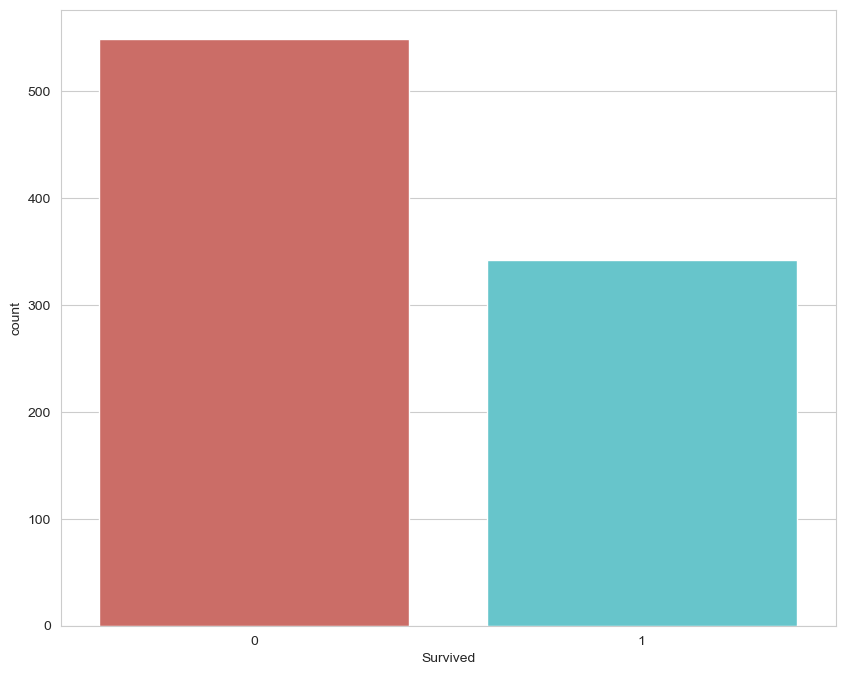

In [1]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import sklearn

from pandas import Series, DataFrame
from pylab import rcParams
from sklearn import preprocessing
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import classification_report

%matplotlib inline

rcParams['figure.figsize'] = 10, 8
sb.set_style('whitegrid')

url = "https://raw.githubusercontent.com/BigDataGal/Python-for-Data-Science/master/titanic-train.csv"

titanic = pd.read_csv(url)

titanic.columns = ['PassengerId','Survived','Pclass','Name','Sex','Age',
                   'SibSp','Parch','Ticket','Fare','Cabin','Embarked']

titanic.head()

sb.countplot(x='Survived', data=titanic, palette='hls')

titanic.isnull().sum()

titanic.info()

        date     value
0 1991-07-01  3.526591
1 1991-08-01  3.180891
2 1991-09-01  3.252221
3 1991-10-01  3.611003
4 1991-11-01  3.565869
      market    month  year  quantity  priceMin  priceMax  priceMod state  \
6654  MUMBAI  January  2004    267100       719       971       849    MS   
6655  MUMBAI  January  2005    275845       261       513       387    MS   
6656  MUMBAI  January  2006    228000       315       488       402    MS   
6657  MUMBAI  January  2007    205200       866      1136       997    MS   
6658  MUMBAI  January  2008    267550       348       550       448    MS   

        city          date  
6654  MUMBAI  January-2004  
6655  MUMBAI  January-2005  
6656  MUMBAI  January-2006  
6657  MUMBAI  January-2007  
6658  MUMBAI  January-2008  


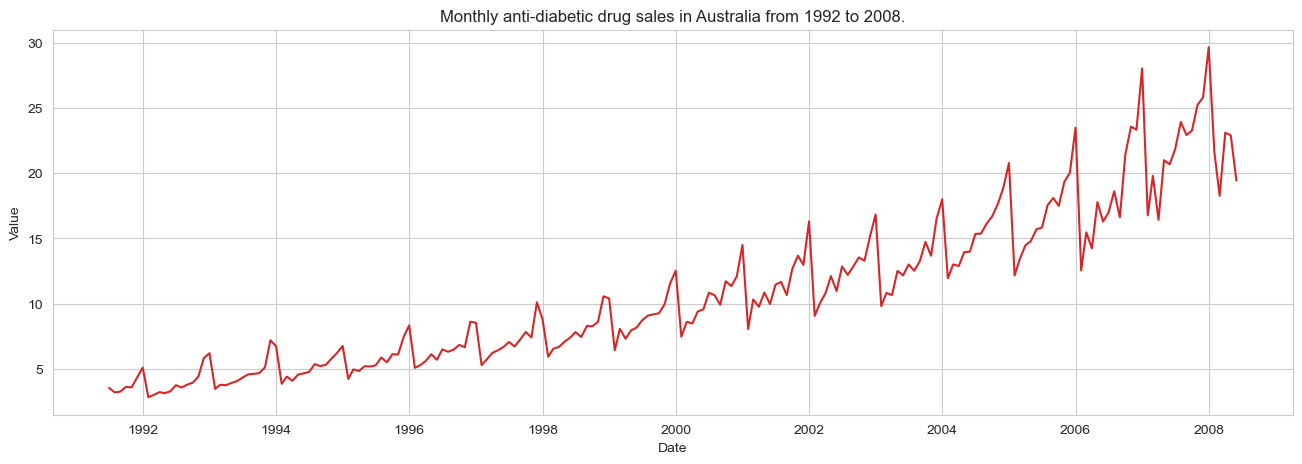

In [3]:
from dateutil.parser import parse
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
plt.rcParams.update({'figure.figsize': (10, 7), 'figure.dpi': 120})

# Import as DataFrame
df = pd.read_csv(
    'https://raw.githubusercontent.com/selva86/datasets/master/a10.csv',
    parse_dates=['date']
)

print(df.head())

# dataset source: https://github.com/rouseguy

df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/MarketArrivals.csv')

df = df.loc[df.market == 'MUMBAI', :]
print(df.head())

# Time series data source: fpppacakge in R.
import matplotlib.pyplot as plt

df = pd.read_csv(
    'https://raw.githubusercontent.com/selva86/datasets/master/a10.csv',
    parse_dates=['date'],
    index_col='date'
)

# Draw Plot
def plot_df(df, x, y, title="", xlabel='Date', ylabel='Value', dpi=100):
    plt.figure(figsize=(16, 5), dpi=dpi)
    plt.plot(x, y, color='tab:red')
    plt.gca().set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.show()

plot_df(
    df,
    x=df.index,
    y=df.value,
    title='Monthly anti-diabetic drug sales in Australia from 1992 to 2008.'
)

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
Fi

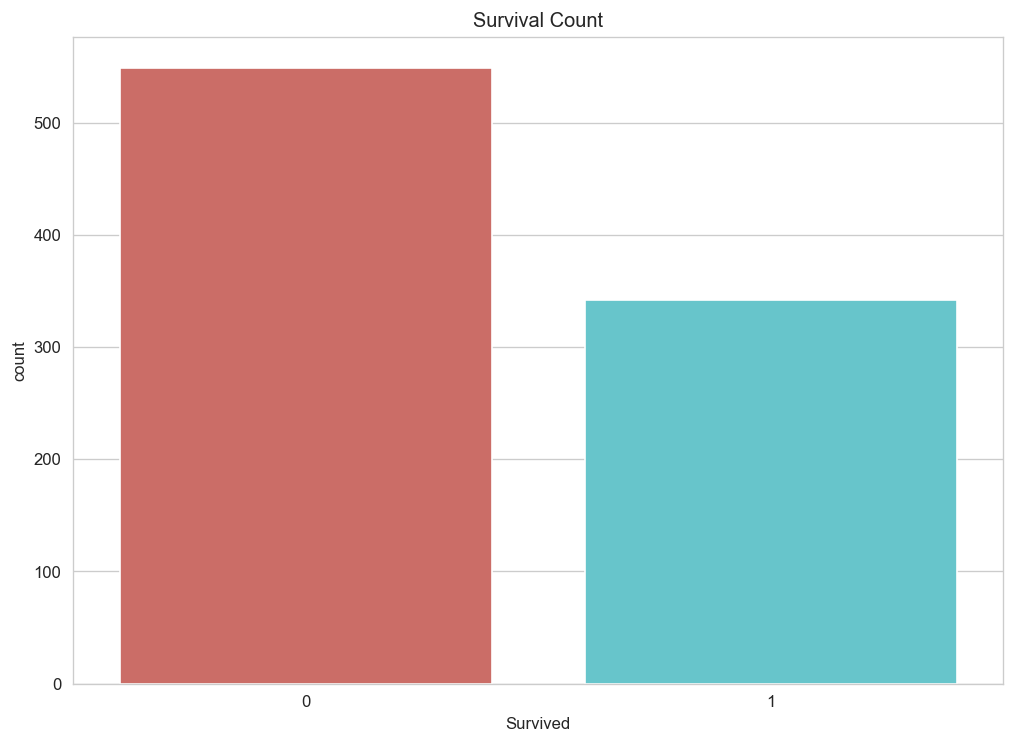


Missing values:

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Training size: 623
Testing size: 268

Confusion Matrix:
 [[151  23]
 [ 27  67]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.87      0.86       174
           1       0.74      0.71      0.73        94

    accuracy                           0.81       268
   macro avg       0.80      0.79      0.79       268
weighted avg       0.81      0.81      0.81       268

Accuracy Score: 0.8134328358208955


In [6]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic = pd.read_csv(url)

print(titanic.head())

titanic.columns = ['PassengerId','Survived','Pclass','Name','Sex','Age','SibSp',
'Parch','Ticket','Fare','Cabin','Embarked']

print("First 5 rows:\n")
print(titanic.head())

sb.countplot(x='Survived', data=titanic, palette='hls')
plt.title("Survival Count")
plt.show()

print("\nMissing values:\n")
print(titanic.isnull().sum())

titanic['Age'].fillna(titanic['Age'].mean(), inplace=True)
titanic['Embarked'].fillna(titanic['Embarked'].mode()[0], inplace=True)
titanic.drop(['Cabin'], axis=1, inplace=True)

label_encoder = preprocessing.LabelEncoder()
titanic['Sex'] = label_encoder.fit_transform(titanic['Sex'])
titanic['Embarked'] = label_encoder.fit_transform(titanic['Embarked'])

X = titanic[['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']]
y = titanic['Survived']

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.3, random_state=10)

print("\nTraining size:", len(X_train))
print("Testing size:", len(X_test))

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))

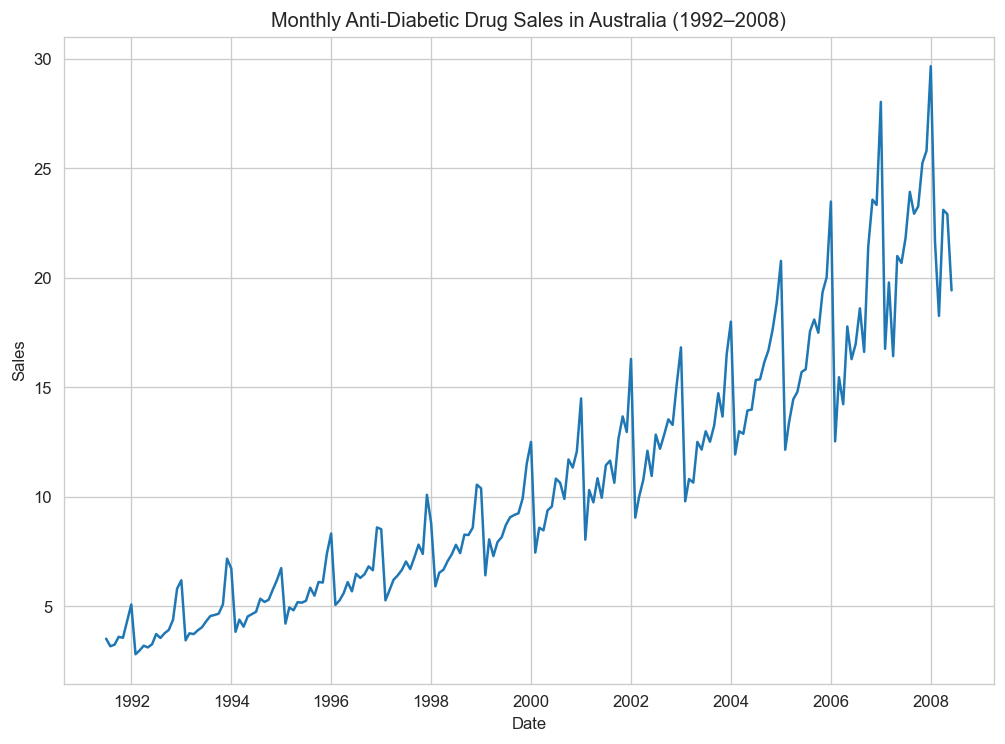


First 5 rows of Mumbai Market Data:

      market    month  year  quantity  priceMin  priceMax  priceMod state  \
6654  MUMBAI  January  2004    267100       719       971       849    MS   
6655  MUMBAI  January  2005    275845       261       513       387    MS   
6656  MUMBAI  January  2006    228000       315       488       402    MS   
6657  MUMBAI  January  2007    205200       866      1136       997    MS   
6658  MUMBAI  January  2008    267550       348       550       448    MS   

        city          date  
6654  MUMBAI  January-2004  
6655  MUMBAI  January-2005  
6656  MUMBAI  January-2006  
6657  MUMBAI  January-2007  
6658  MUMBAI  January-2008  

Number of records for Mumbai market: 146


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv(
    "https://raw.githubusercontent.com/selva86/datasets/master/a10.csv",
    parse_dates=['date'], index_col='date'
)

plt.figure(figsize=(10,7))
plt.plot(df.index, df.value)
plt.title("Monthly Anti-Diabetic Drug Sales in Australia (1992–2008)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

df_market = pd.read_csv(
    "https://raw.githubusercontent.com/selva86/datasets/master/MarketArrivals.csv"
)

df_mumbai = df_market[df_market.market == "MUMBAI"]

print("\nFirst 5 rows of Mumbai Market Data:\n")
print(df_mumbai.head())

print("\nNumber of records for Mumbai market:", len(df_mumbai))